In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [13]:
# Change these paths to match your Google Drive files
color_image_path = "/content/drive/MyDrive/AI ML/collab/week2/color.png"
gray_image_path = "/content/drive/MyDrive/AI ML/collab/week2/lena_gray.gif"
pca_image_path = "/content/drive/MyDrive/AI ML/collab/week2/lena_gray.gif"

def load_image_from_drive(file_path):
    """Open an image from Google Drive and return a PIL image."""
    return Image.open(file_path)

def show_image(image_array, title="", cmap=None, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image_array, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
color_image = load_image_from_drive(color_image_path).convert("RGB")
color_array = np.array(color_image)

print("Color image path:", color_image_path)
print("Color image shape:", color_array.shape)
print("Color image mode:", color_image.mode)


Color image path: /content/drive/MyDrive/AI ML/collab/week2/color.png
Color image shape: (340, 512, 3)
Color image mode: RGB


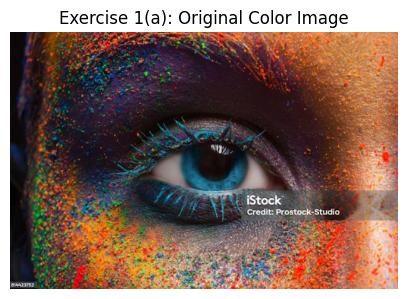

In [16]:
# 1(a) Read and display the color image
show_image(color_array, "Exercise 1(a): Original Color Image")

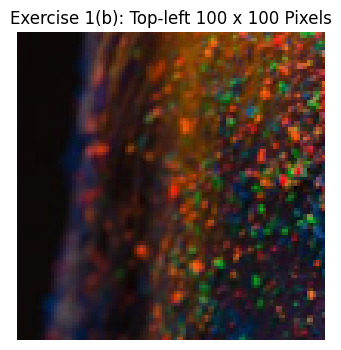

In [17]:
# 1(b) Show the top-left 100 x 100 pixels
top_left_color = color_array[:100, :100]
show_image(top_left_color, "Exercise 1(b): Top-left 100 x 100 Pixels", figsize=(4, 4))

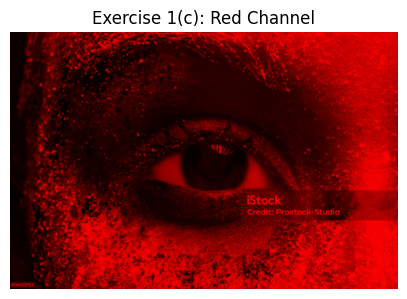

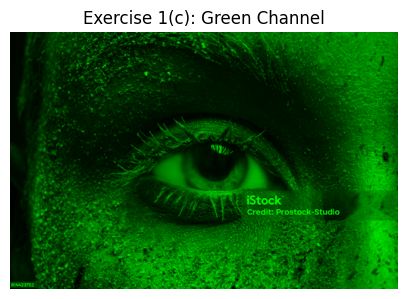

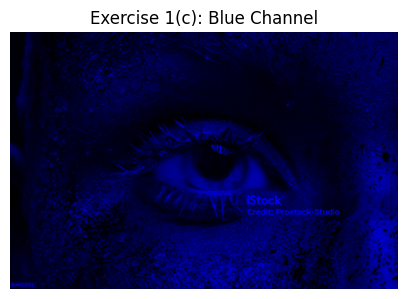

In [40]:
# 1(c) Separate and display the Red, Green, and Blue channels
red_channel = color_array.copy()
red_channel[:, :, 1] = 0
red_channel[:, :, 2] = 0

green_channel = color_array.copy()
green_channel[:, :, 0] = 0
green_channel[:, :, 2] = 0

blue_channel = color_array.copy()
blue_channel[:, :, 0] = 0
blue_channel[:, :, 1] = 0

show_image(red_channel, "Exercise 1(c): Red Channel")
show_image(green_channel, "Exercise 1(c): Green Channel")
show_image(blue_channel, "Exercise 1(c): Blue Channel")

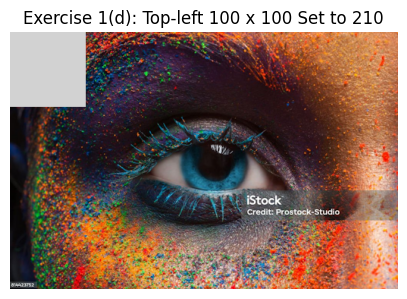

In [19]:
# 1(d) Modify the top-left 100 x 100 pixels to 210
modified_color = color_array.copy()
modified_color[:100, :100] = 210   # sets R, G, and B values to 210

show_image(modified_color, "Exercise 1(d): Top-left 100 x 100 Set to 210")

# Exercise 2 — Grayscale image operations


In [20]:
gray_image = load_image_from_drive(gray_image_path).convert("L")
gray_array = np.array(gray_image)

print("Grayscale image path:", gray_image_path)
print("Grayscale image shape:", gray_array.shape)
print("Grayscale image mode:", gray_image.mode)


Grayscale image path: /content/drive/MyDrive/AI ML/collab/week2/lena_gray.gif
Grayscale image shape: (512, 512)
Grayscale image mode: L


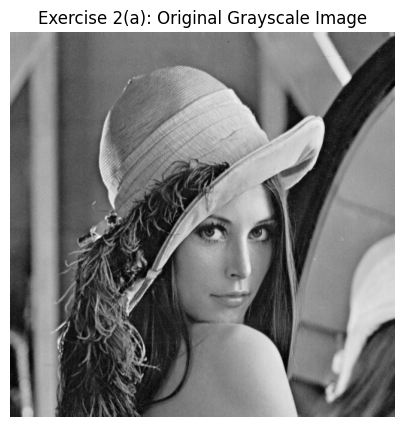

In [21]:
# 2(a) Read and display the grayscale image
show_image(gray_array, "Exercise 2(a): Original Grayscale Image", cmap="gray")

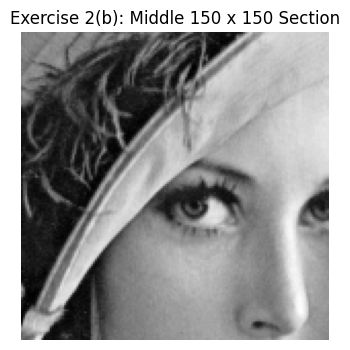

In [22]:
# 2(b) Extract the middle 150 x 150 section
height, width = gray_array.shape
center_row = height // 2
center_col = width // 2
half_size = 75

middle_section = gray_array[
    center_row - half_size:center_row + half_size,
    center_col - half_size:center_col + half_size
]

show_image(middle_section, "Exercise 2(b): Middle 150 x 150 Section", cmap="gray", figsize=(4, 4))

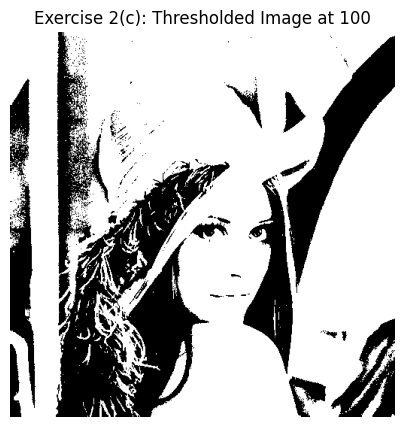

In [23]:
# 2(c) Thresholding with threshold value = 100
threshold_value = 100
threshold_image = np.where(gray_array < threshold_value, 0, 255).astype(np.uint8)

show_image(threshold_image, "Exercise 2(c): Thresholded Image at 100", cmap="gray")

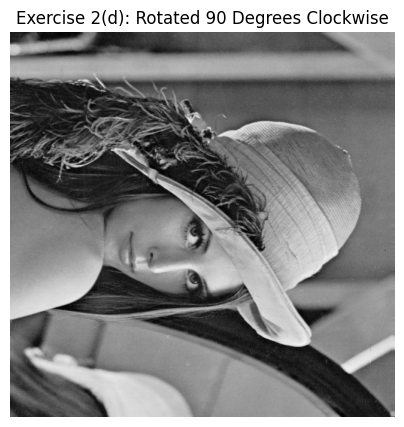

In [24]:
# 2(d) Rotate the grayscale image 90 degrees clockwise
rotated_gray = np.rot90(gray_array, k=-1)

show_image(rotated_gray, "Exercise 2(d): Rotated 90 Degrees Clockwise", cmap="gray")

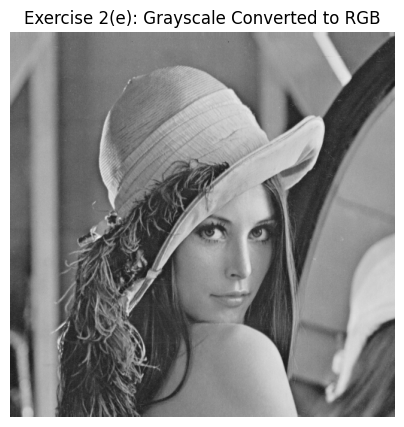

RGB image shape: (512, 512, 3)


In [25]:
# 2(e) Convert grayscale image to RGB
gray_to_rgb = np.stack([gray_array, gray_array, gray_array], axis=-1)

show_image(gray_to_rgb, "Exercise 2(e): Grayscale Converted to RGB")
print("RGB image shape:", gray_to_rgb.shape)

# Exercise 3 — PCA from scratch for image compression


PCA image path: /content/drive/MyDrive/AI ML/collab/week2/lena_gray.gif
PCA image shape: (512, 512)
PCA image mode: L


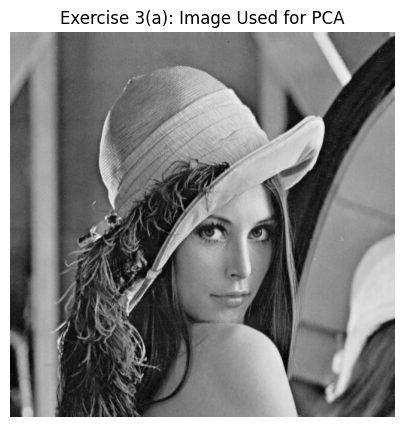

In [26]:
pca_image = load_image_from_drive(pca_image_path)

# Convert to grayscale if needed
if pca_image.mode != "L":
    pca_image = pca_image.convert("L")

pca_array = np.array(pca_image).astype(np.float64)

print("PCA image path:", pca_image_path)
print("PCA image shape:", pca_array.shape)
print("PCA image mode:", pca_image.mode)

show_image(pca_array, "Exercise 3(a): Image Used for PCA", cmap="gray")


In [27]:
# 3(b) Center and standardize the data
# Each column is treated as a feature
mean_vector = np.mean(pca_array, axis=0)
std_vector = np.std(pca_array, axis=0)

# Avoid division by zero
std_vector[std_vector == 0] = 1

standardized_data = (pca_array - mean_vector) / std_vector

print("Standardized data shape:", standardized_data.shape)

Standardized data shape: (512, 512)


In [28]:
# 3(c) Compute the covariance matrix
covariance_matrix = np.cov(standardized_data, rowvar=False)

print("Covariance matrix shape:", covariance_matrix.shape)

Covariance matrix shape: (512, 512)


In [29]:
# 3(d) Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# Sort from largest to smallest
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Top 10 eigenvalues:")
print(eigenvalues[:10])
print("Eigenvectors shape:", eigenvectors.shape)

Top 10 eigenvalues:
[114.55249269  77.58472773  47.46688575  41.83892136  33.31340224
  24.7555424   21.7401561   12.80972604  10.01263851   9.05609862]
Eigenvectors shape: (512, 512)


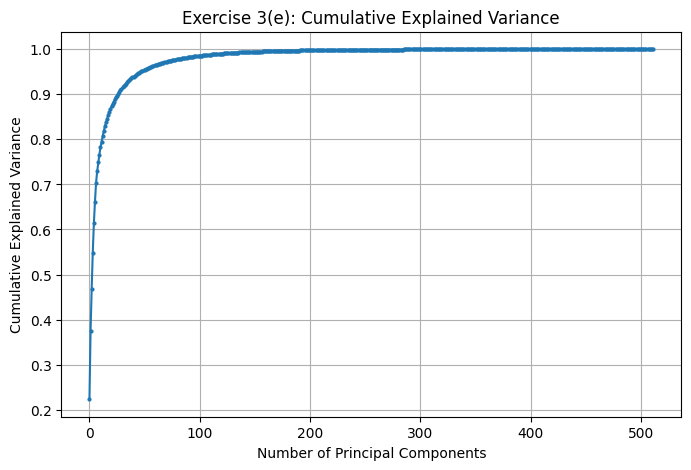

In [30]:
# 3(e) Explained variance and cumulative explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_explained_variance, marker="o", markersize=2)
plt.title("Exercise 3(e): Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [31]:
# Choose k using cumulative explained variance
# We find the number of components needed for 95% variance
k_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
print("Components needed for at least 95% variance:", k_95)

# Test four different principal-component combinations
candidate_k_values = [10, 25, 50, k_95]

# Keep values valid and unique
k_values = []
max_components = eigenvectors.shape[1]

for k in candidate_k_values:
    k = max(1, min(int(k), max_components))
    if k not in k_values:
        k_values.append(k)

# If duplicates happen, fill with nearby valid values
extra_candidate = 5
while len(k_values) < 4:
    if extra_candidate not in k_values and extra_candidate <= max_components:
        k_values.insert(0, extra_candidate)
    extra_candidate += 5

k_values = sorted(k_values)
print("Four k values used for reconstruction:", k_values)

Components needed for at least 95% variance: 48
Four k values used for reconstruction: [10, 25, 48, 50]


In [32]:
# 3(f) Reconstruct the image using different numbers of principal components
reconstructed_images = []

for k in k_values:
    selected_vectors = eigenvectors[:, :k]

    reduced_data = standardized_data @ selected_vectors
    reconstructed_standardized = reduced_data @ selected_vectors.T

    # Convert back to original scale
    reconstructed_image = (reconstructed_standardized * std_vector) + mean_vector
    reconstructed_image = np.clip(reconstructed_image, 0, 255)

    reconstructed_images.append(reconstructed_image)

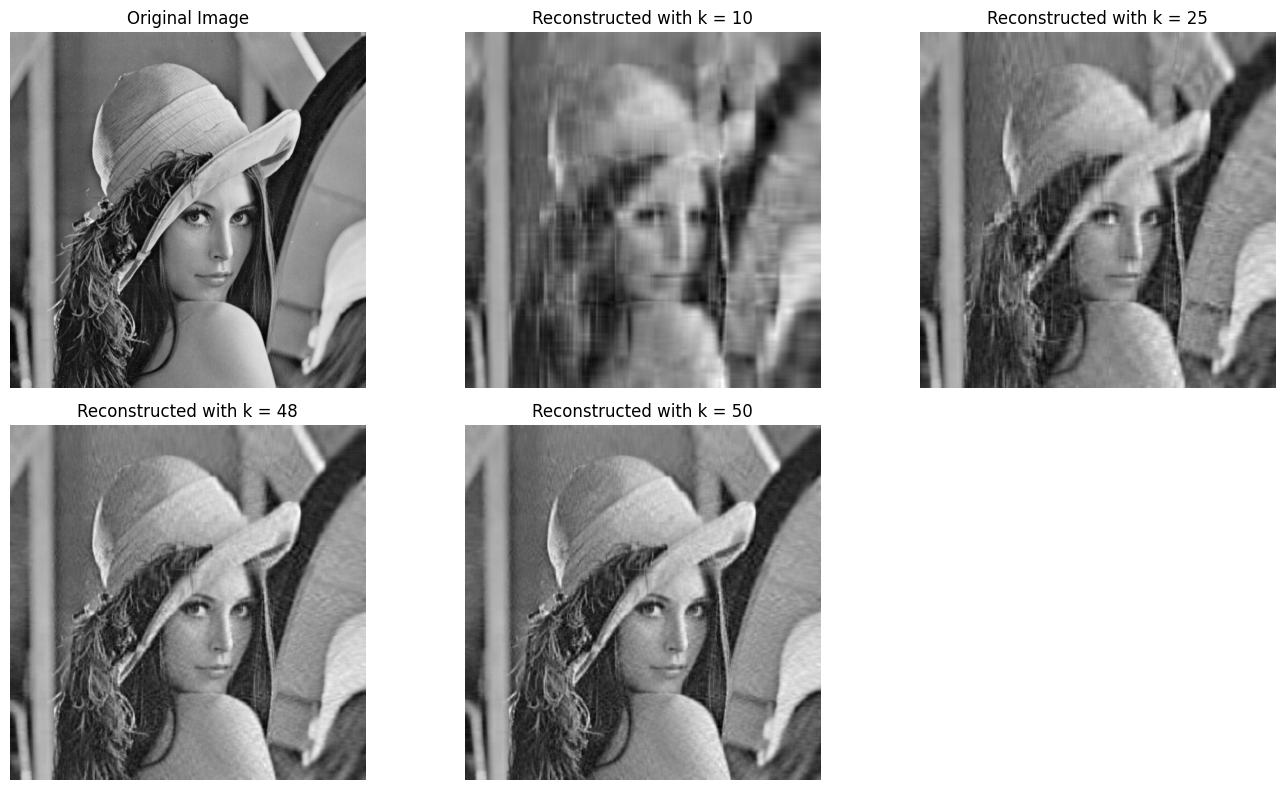

In [33]:
# Show original and reconstructed images
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(pca_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(k_values):
    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructed_images[i], cmap="gray")
    plt.title(f"Reconstructed with k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# Compare retained variance and reconstruction error
for i, k in enumerate(k_values):
    mse = np.mean((pca_array - reconstructed_images[i]) ** 2)
    retained_variance = cumulative_explained_variance[k - 1] * 100

    print(f"k = {k}")
    print(f"Retained variance = {retained_variance:.2f}%")
    print(f"Mean squared error = {mse:.2f}")


k = 10
Retained variance = 76.63%
Mean squared error = 367.12
k = 25
Retained variance = 89.30%
Mean squared error = 156.41
k = 48
Retained variance = 95.08%
Mean squared error = 70.53
k = 50
Retained variance = 95.34%
Mean squared error = 66.78
